In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1
!ls

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1
 all_traj_DNAonly.npz		 Energy_Eval.ipynb
 checkpoints			 eval_input.xyz
 Conditional_RealNVP.ipynb	 logs
 cond_seq_0.pdb			 merged_data.npz
 cond_seq_1.5.pdb		 mlp_seq_100.pdb
 cond_seq_1.5_relaxed.pdb	 mlp_seq_120.pdb
 cond_seq_-18_relaxed.pdb	 mlp_seq_140.pdb
 cond_seq_18_relaxed.pdb	 mlp_seq_140_unrelaxed.pdb
 cond_seq_1.pdb			'RealNVP with MLP.ipynb'
 cond_seq_-1_relaxed.pdb	 results
 cond_seq_1_relaxed.pdb		 stretch1.rst7
 cond_seq_2.4_relaxed.pdb	 stretch2.rst7
 cond_seq_3.5_relaxed.pdb	 stretch3.rst7
 cond_seq_4.5_relaxed.pdb	 stretch4.rst7
 dna_mace_allfloat32.pt		 topology1.prmtop
 dna_mace_compiled.model	 topology2.prmtop
 dna_mace_dataset.xyz		 topology3.prmtop
 dna_mace_fixed.pt		 topology4.prmtop
 dna_mace.model			 topology.prmtop
 E0s.txt			 V1.ipynb
 energies_all_list05.json	 V2.ipynb
 energies_all_list15.json	 V3.ipynb
 energies_all_list.json		 V4.ipynb
 energies_all_list_low-05.json	 V5.ipyn

In [3]:
!pip install netCDF4
!pip install parmed
!pip install openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 103.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 100.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471509 sha256=91d5a74284c2d47766368d554b15ef28afe874be1b4d071b4e6ddb56efe2a1c4
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
Successfully built parmed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 27.8 MB/s eta 0:00:00


In [4]:
import os
import re
import tqdm
import json
import time
import netCDF4
import numpy as np
import parmed as pmd
from tqdm import tqdm

import math
import pickle
import argparse
from sys import exit
from sklearn import datasets
import matplotlib.pyplot as plt

import openmm
from openmm import app, openmm
from openmm import unit, LangevinIntegrator
from openmm.app import AmberPrmtopFile, Simulation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]
boxes  = data["boxes"]

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


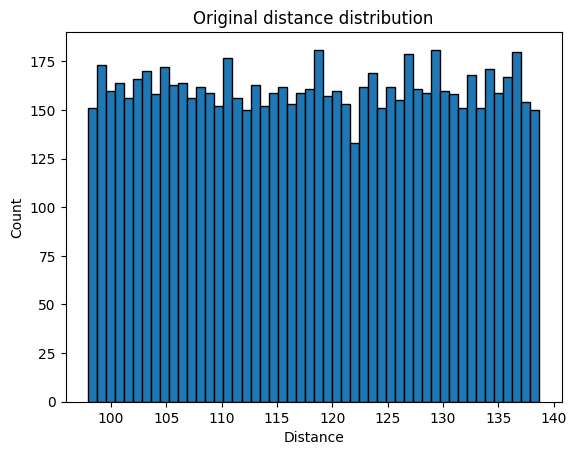

In [7]:
p1, p2, p3, p4 = 30, 943, 946, 1871

def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):
    return math.sqrt(np.sum((one - two)**2))

def compute_distances(trajectories, p1, p2, p3, p4):
    distances = []
    for coords in trajectories:
        leftEnd  = middlePoint(coords[p1], coords[p4])
        rightEnd = middlePoint(coords[p2], coords[p3])
        distances.append(dist(leftEnd, rightEnd))
    return torch.tensor(distances, dtype=torch.float32).unsqueeze(1)

distances_orig = compute_distances(coords, p1, p2, p3, p4)

plt.hist(distances_orig.numpy(), bins=50, edgecolor='black')
plt.title("Original distance distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

In [8]:
coords_np = coords.astype(np.float32)
coords_flat = coords_np.reshape(8050, -1)
coords_flat = torch.from_numpy(coords_flat)
D = coords_flat.shape[1]
print("Flattened dimension D:", D)

Flattened dimension D: 5682


In [9]:
x_train_full = coords_flat
x_mean = x_train_full.mean(dim=0, keepdim=True)
x_std  = x_train_full.std(dim=0, keepdim=True) + 1e-6
x_all_norm = (coords_flat - x_mean) / x_std

In [10]:
c_all = distances_orig
c_train_full = c_all
c_mean = c_train_full.mean(dim=0, keepdim=True)
c_std  = c_train_full.std(dim=0, keepdim=True) + 1e-6
c_all_norm = (c_all - c_mean) / c_std

In [11]:
train_x = x_all_norm
train_c = c_all_norm

print("train_x:", train_x.shape, "train_c:", train_c.shape)

train_x: torch.Size([8050, 5682]) train_c: torch.Size([8050, 1])


In [12]:
batch_size = 16

train_ds = TensorDataset(train_x, train_c)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

In [13]:
class CondNet(nn.Module):
    def __init__(self, cond_dim=1, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim),
            nn.ReLU(),
        )

    def forward(self, c):
        return self.net(c)


In [14]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, cond_emb_dim, mask):
        super().__init__()
        self.dim = dim
        self.register_buffer("mask", mask.float())

        input_dim = dim + cond_emb_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim * 2),
        )

    def forward(self, x, cond_emb):

        m = self.mask.to(x.device)
        x_masked = x * m

        inp = torch.cat([x_masked, cond_emb], dim=1)
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        y = x_masked + (1 - m) * (x * scale + t)
        logdet = ((1 - m) * s).sum(dim=1)

        return y, logdet

    def inverse(self, y, cond_emb):

        m = self.mask.to(y.device)
        y_masked = y * m

        inp = torch.cat([y_masked, cond_emb], dim=1)
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        x = y_masked + (1 - m) * ((y - t) / scale)
        logdet = -((1 - m) * s).sum(dim=1)

        return x, logdet

In [15]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=6, hidden_dim=512,
                 cond_dim=1, cond_emb_dim=32):
        super().__init__()
        self.dim = dim
        self.cond_net = CondNet(cond_dim=cond_dim, embed_dim=cond_emb_dim)

        masks = []
        for i in range(n_layers):
            mask = torch.zeros(dim)
            mask[i % 2 :: 2] = 1.0
            masks.append(mask)

        self.layers = nn.ModuleList([
            CouplingLayer(dim, hidden_dim, cond_emb_dim, masks[i])
            for i in range(n_layers)
        ])

    def forward(self, x, c):
        cond_emb = self.cond_net(c)
        logdet_sum = torch.zeros(x.shape[0], device=x.device)

        z = x
        for layer in self.layers:
            z, logdet = layer(z, cond_emb)
            logdet_sum += logdet
        return z, logdet_sum

    def inverse(self, z, c):
        cond_emb = self.cond_net(c)
        logdet_sum = torch.zeros(z.shape[0], device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, logdet = layer.inverse(x, cond_emb)
            logdet_sum += logdet

        return x, logdet_sum


In [18]:
model = RealNVP(dim=D, n_layers=6, hidden_dim=512,
                cond_dim=1, cond_emb_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [19]:
def flow_nll(model, x, c):
    z, logdet = model(x, c)
    log_pz = -0.5 * torch.sum(z**2, dim=1)
    log_px = log_pz + logdet
    nll = -log_px.mean()
    return nll

n_epochs = 200
train_losses = []
for epoch in range(1, n_epochs+1):
    model.train()
    train_loss = 0.0
    for x_batch, c_batch in train_loader:
        x_batch = x_batch.to(device)
        c_batch = c_batch.to(device)

        optimizer.zero_grad()
        loss = flow_nll(model, x_batch, c_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    print(f"Epoch {epoch:03d} | train NLL: {train_loss:.4f}")

Epoch 001 | train NLL: -1784.2071
Epoch 002 | train NLL: -4599.2547
Epoch 003 | train NLL: -5619.1387
Epoch 004 | train NLL: -6254.4683
Epoch 005 | train NLL: -6709.8361
Epoch 006 | train NLL: -7092.5865
Epoch 007 | train NLL: -7418.8894
Epoch 008 | train NLL: -7702.1665
Epoch 009 | train NLL: -7950.2102
Epoch 010 | train NLL: -8158.6319
Epoch 011 | train NLL: -8353.0185
Epoch 012 | train NLL: -8520.4188
Epoch 013 | train NLL: -8696.0931
Epoch 014 | train NLL: -8837.1973
Epoch 015 | train NLL: -8978.4583
Epoch 016 | train NLL: -9124.7763
Epoch 017 | train NLL: -9234.0760
Epoch 018 | train NLL: -9367.8621
Epoch 019 | train NLL: -9445.4688
Epoch 020 | train NLL: -9568.2271
Epoch 021 | train NLL: -9656.6475
Epoch 022 | train NLL: -9740.8416
Epoch 023 | train NLL: -9832.3143
Epoch 024 | train NLL: -9920.6750
Epoch 025 | train NLL: -10000.1329
Epoch 026 | train NLL: -10066.8398
Epoch 027 | train NLL: -10147.7336
Epoch 028 | train NLL: -10217.4400
Epoch 029 | train NLL: -10302.6062
Epoch 030

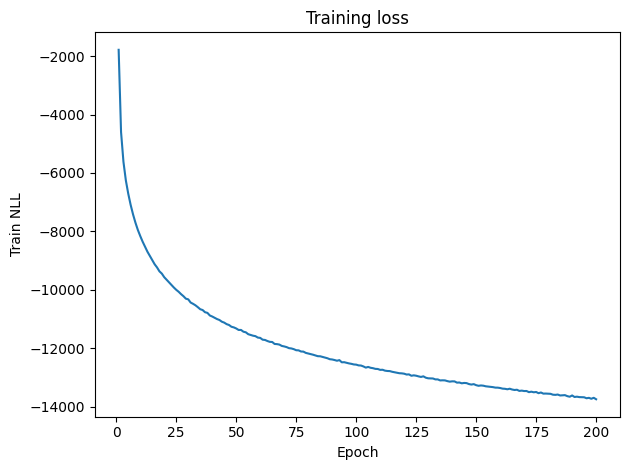

In [20]:
plt.figure()
plt.plot(range(1, n_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train NLL")
plt.title("Training loss")
plt.tight_layout()
plt.show()

In [21]:
model.eval()

def sample_structs(c_norm, n_samples=1):

    with torch.no_grad():
        z = torch.randn(n_samples, D, device=device)
        c = torch.full((n_samples, 1), float(c_norm), device=device)
        x_norm, _ = model.inverse(z, c)


        x = x_norm.cpu() * x_std + x_mean
        x = x.reshape(n_samples, 1894, 3)
    return x

samples_low  = sample_structs(c_norm=-2.0, n_samples=1)
samples_mid  = sample_structs(c_norm=1.0,  n_samples=1)
samples_high = sample_structs(c_norm=+0.5, n_samples=1)

print("shapes:", samples_low.shape, samples_mid.shape, samples_high.shape)

shapes: torch.Size([1, 1894, 3]) torch.Size([1, 1894, 3]) torch.Size([1, 1894, 3])


In [22]:
def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):

    if isinstance(one, np.ndarray):
        return float(np.linalg.norm(one - two))
    else:
        return torch.norm(one - two).item()

def compute_distance_single(coords, p1, p2, p3, p4):

    p1 -= 1; p2 -= 1; p3 -= 1; p4 -= 1

    leftEnd  = middlePoint(coords[p1], coords[p4])
    rightEnd = middlePoint(coords[p2], coords[p3])

    return dist(leftEnd, rightEnd)

In [23]:
def measure_distance_vs_condition(c_norm_values, n_samples_per_cond=50):
    results = []
    for c_val in c_norm_values:
        dists = []
        for _ in range(n_samples_per_cond):

            sample = sample_structs(c_norm=c_val, n_samples=1)[0]
            d = compute_distance_single(sample, p1, p2, p3, p4)
            dists.append(d)
        dists = np.array(dists)
        mean_d = dists.mean()
        std_d  = dists.std()
        results.append((c_val, mean_d, std_d))
        print(f"c_norm={c_val:+.2f} → distance = {mean_d:.2f} ± {std_d:.2f} Å")
    return results

c_values = np.linspace(-2.0, 2.0, 9)
results = measure_distance_vs_condition(c_values, n_samples_per_cond=50)

c_norm=-2.00 → distance = 98.25 ± 1.61 Å
c_norm=-1.50 → distance = 101.34 ± 1.61 Å
c_norm=-1.00 → distance = 105.88 ± 1.26 Å
c_norm=-0.50 → distance = 111.91 ± 0.94 Å
c_norm=+0.00 → distance = 117.48 ± 0.80 Å
c_norm=+0.50 → distance = 123.42 ± 0.65 Å
c_norm=+1.00 → distance = 129.68 ± 0.78 Å
c_norm=+1.50 → distance = 134.09 ± 0.93 Å
c_norm=+2.00 → distance = 137.16 ± 0.99 Å


In [24]:
import time
import numpy as np
import parmed as pmd
from openmm import unit, openmm
from openmm import app

def minimize_coords_with_openmm(
    coords,
    top_file,
    rst_file,
    n_atoms_keep=1894,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,  # "CUDA", "OpenCL", "CPU"
):

    coords = np.asarray(coords)
    assert coords.shape == (1, n_atoms_keep, 3), \
        f"coords must be shape (1, {n_atoms_keep}, 3), got {coords.shape}"

    if tolerance is None:
        tolerance = 10.0 * unit.kilojoules_per_mole / unit.nanometer

    print("Setting up OpenMM system for minimization...")
    structure = pmd.load_file(top_file, rst_file)[:n_atoms_keep]

    system = structure.createSystem(
        nonbondedMethod=app.CutoffNonPeriodic,
        nonbondedCutoff=1.2 * unit.nanometer,
        constraints=None,
        implicitSolvent=app.OBC2 if use_gb else None,
    )
    topology = structure.topology

    print("Forces present in system:")
    for i, f in enumerate(system.getForces()):
        print(f"  [{i}] {f.__class__.__name__}")

    integrator = openmm.VerletIntegrator(1.0 * unit.femtoseconds)

    if platform_name is not None:
        platform = openmm.Platform.getPlatformByName(platform_name)
        simulation = app.Simulation(topology, system, integrator, platform)
        print(f"Using platform: {platform_name}")
    else:
        simulation = app.Simulation(topology, system, integrator)
        platform = simulation.context.getPlatform()
        print(f"Using platform: {platform.getName()}")


    coords_nm = coords[0] * 0.1
    simulation.context.setPositions(coords_nm)


    state0 = simulation.context.getState(getEnergy=True)
    E0 = state0.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)
    print(f"Initial potential energy: {E0:.2f} kcal/mol")

    print(
        f"Starting minimization (max_iterations={max_iterations}, "
        f"tolerance={tolerance})"
    )
    t0 = time.perf_counter()
    simulation.minimizeEnergy(tolerance=tolerance, maxIterations=max_iterations)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    print(f"Minimization finished in {elapsed:.2f} s")


    state = simulation.context.getState(getPositions=True, getEnergy=True)
    E_final = state.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)

    # Energies by term (energies only; keys are names)
    energies = {}
    for i, f in enumerate(system.getForces()):
        st_i = simulation.context.getState(getEnergy=True, groups=1 << i)
        energies[f.__class__.__name__] = st_i.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)

    # Optional: map to nicer “bond/angle/…” labels (works when those forces exist)
    labels = {
        "HarmonicBondForce": "bond",
        "HarmonicAngleForce": "angle",
        "PeriodicTorsionForce": "torsion",
        "RBTorsionForce": "torsion_rb",
        "NonbondedForce": "nonbonded",
    }
    energies_all = {labels.get(k, k): v for k, v in energies.items()}

    print(f"Final potential energy:   {E_final:.2f} kcal/mol")

    positions_nm = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    coords_min_angs = np.array(positions_nm) * 10.0
    coords_min_angs = coords_min_angs[np.newaxis, ...]

    return coords_min_angs, E0, E_final, elapsed, energies_all


In [25]:
def save_generated_pdb(
    coords,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="generated_sample.pdb",
    relax=False,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,
):

    coords = np.asarray(coords)
    assert coords.shape == (1, n_atoms_keep, 3), \
        f"coords must be shape (1, {n_atoms_keep}, 3), got {coords.shape}"

    if relax:
        print("=== Running OpenMM minimization before saving PDB ===")
        coords_relaxed, E0, E_final, elapsed, _ = minimize_coords_with_openmm(
            coords=coords,
            top_file=topology_file,
            rst_file=rst_file,
            n_atoms_keep=n_atoms_keep,
            use_gb=use_gb,
            max_iterations=max_iterations,
            tolerance=tolerance,
            platform_name=platform_name,
        )
        coords_to_save = coords_relaxed
        print(
            f"Energy change: {E0:.2f} → {E_final:.2f} kcal/mol "
            f"(ΔE = {E_final - E0:.2f} kcal/mol)"
        )
        print(f"Minimization time: {elapsed:.2f} s")
    else:
        coords_to_save = coords
        print("Skipping minimization; saving raw generated coordinates.")

    full = pmd.load_file(topology_file, rst_file)
    print(f"Full structure atoms:   {len(full.atoms)}")

    trimmed = full[:n_atoms_keep]
    print(f"Trimmed structure atoms: {len(trimmed.atoms)}")

    trimmed.coordinates = coords_to_save[0]

    os.makedirs(os.path.dirname(out_file) or ".", exist_ok=True)

    trimmed.save(out_file, overwrite=True)
    print(f"✅ Saved PDB: {out_file}")

    return trimmed

In [26]:
coords_gen = sample_structs(c_norm=1.5, n_samples=2)[1]
coords_gen = coords_gen[np.newaxis, ...]

In [27]:
pdb_struct = save_generated_pdb(
    coords=coords_gen,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="cond_seq_1.5.pdb",
    relax=True,
    use_gb=True,
    max_iterations=500,
    platform_name="OpenCL",
)

=== Running OpenMM minimization before saving PDB ===
Setting up OpenMM system for minimization...
Forces present in system:
  [0] HarmonicBondForce
  [1] HarmonicAngleForce
  [2] PeriodicTorsionForce
  [3] NonbondedForce
  [4] CustomGBForce
  [5] CMMotionRemover
Using platform: OpenCL
Initial potential energy: 1025060.30 kcal/mol
Starting minimization (max_iterations=500, tolerance=10.0 kJ/(nm mol))
Minimization finished in 0.40 s
Final potential energy:   -17535.30 kcal/mol
Energy change: 1025060.30 → -17535.30 kcal/mol (ΔE = -1042595.60 kcal/mol)
Minimization time: 0.40 s
Full structure atoms:   70688
Trimmed structure atoms: 1894
✅ Saved PDB: cond_seq_1.5.pdb


In [28]:
PARAM_SETS = [
    (-1.5, "energies_all_list_low-15.json"),
    (-0.5, "energies_all_list_low-05.json"),
    ( 0.5, "energies_all_list05.json"),
    ( 1.5, "energies_all_list15.json"),
]

def run_batch(c_norm: float, out_path: str, n_samples: int = 500, log_every: int = 25):
    coords_gen = sample_structs(c_norm=c_norm, n_samples=n_samples)
    energies_list = []

    t0 = time.perf_counter()
    for i in range(n_samples):
        t_i0 = time.perf_counter()

        i_coords = coords_gen[i]
        _, _, _, _, energies_all = minimize_coords_with_openmm(
            coords=i_coords[np.newaxis, ...],
            top_file="topology1.prmtop",
            rst_file="stretch1.rst7",
            n_atoms_keep=1894,
            use_gb=True,
            max_iterations=500,
            platform_name="OpenCL",
        )
        energies_list.append(energies_all)

        # timing / progress
        if (i + 1) % log_every == 0 or (i + 1) == n_samples:
            elapsed = time.perf_counter() - t0
            avg = elapsed / (i + 1)
            remaining = avg * (n_samples - (i + 1))
            last = time.perf_counter() - t_i0

            print(
                f"[c_norm={c_norm:+.1f}] {i+1:>4}/{n_samples} | "
                f"last={last:6.2f}s avg={avg:6.2f}s | "
                f"elapsed={elapsed/60:6.2f}m ETA={remaining/60:6.2f}m"
            )

    # write output
    with open(out_path, "w") as f:
        json.dump(energies_list, f, indent=2)

    total = time.perf_counter() - t0
    print(f"✅ Wrote {len(energies_list)} samples to {out_path} "
          f"(total {total/60:.2f}m, avg {total/len(energies_list):.2f}s/sample)")

    return energies_list


for c_norm, out_path in PARAM_SETS:
    run_batch(c_norm=c_norm, out_path=out_path, n_samples=500, log_every=25)


Streaming output truncated to the last 5000 lines.
Initial potential energy: 519847.85 kcal/mol
Starting minimization (max_iterations=500, tolerance=10.0 kJ/(nm mol))
Minimization finished in 0.28 s
Final potential energy:   -17489.52 kcal/mol
Setting up OpenMM system for minimization...
Forces present in system:
  [0] HarmonicBondForce
  [1] HarmonicAngleForce
  [2] PeriodicTorsionForce
  [3] NonbondedForce
  [4] CustomGBForce
  [5] CMMotionRemover
Using platform: OpenCL
Initial potential energy: 292190.23 kcal/mol
Starting minimization (max_iterations=500, tolerance=10.0 kJ/(nm mol))
Minimization finished in 0.23 s
Final potential energy:   -17503.15 kcal/mol
Setting up OpenMM system for minimization...
Forces present in system:
  [0] HarmonicBondForce
  [1] HarmonicAngleForce
  [2] PeriodicTorsionForce
  [3] NonbondedForce
  [4] CustomGBForce
  [5] CMMotionRemover
Using platform: OpenCL
Initial potential energy: 65529.59 kcal/mol
Starting minimization (max_iterations=500, tolerance=

In [ ]:
# @title
"""import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def get_bond_angle(energies_list):
    bond = np.array([d.get("bond", np.nan) for d in energies_list], dtype=float)
    angle = np.array([d.get("angle", np.nan) for d in energies_list], dtype=float)
    mask = np.isfinite(bond) & np.isfinite(angle)
    return bond[mask], angle[mask]

bond_low, angle_low = get_bond_angle(energies_all_list_low)
bond_all, angle_all = get_bond_angle(energies_all_list)

bond_v = np.concatenate([bond_low, bond_all])
angle_v = np.concatenate([angle_low, angle_all])


score = np.abs(bond_v) + np.abs(angle_v)
k = min(40, len(score))
keep = np.argsort(score)[:-k] if k > 0 else np.arange(len(score))
bond_f, angle_f = bond_v[keep], angle_v[keep]


xmin, xmax = 109.0, 123.0
ymin, ymax = 325.0, 372.0

N = 300
xx, yy = np.mgrid[xmin:xmax:complex(N), ymin:ymax:complex(N)]
grid = np.vstack([xx.ravel(), yy.ravel()])


bw = 0.2
kde = gaussian_kde(np.vstack([bond_f, angle_f]), bw_method=bw)
p = kde(grid).reshape(xx.shape)

eps = 1e-4
p = np.clip(p, eps, None)
F = -np.log(p)
F = F - np.min(F)

Fmax = np.percentile(F, 99)
F_plot = np.clip(F, 0, Fmax)

plt.figure()
levels = 30
cf = plt.contourf(xx, yy, F_plot, levels=levels, cmap="inferno")
plt.contour(xx, yy, F_plot, levels=10, linewidths=0.6)

plt.colorbar(cf, label="")
plt.xlabel("Bond energy (kcal/mol)")
plt.ylabel("Angle energy (kcal/mol)")
plt.title("")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()
"""